# Trabajo Semanal N°4 :'Primeras nociones de Estimacion Espectral'
### Alumno: Magdalena Guida

### APS - 1er cuatrimestre 2026

El objetivo de este trabajo es el analisis del comportamiento de distintas ventanas aplicadas a una misma señal a partir de sus estimadores. 
Los estimadores son funciones aplicadas sobre datos muestrales, que sirven para reproducir el valor de un dato desconocido. En este caso se utilizan estimadores de amplitud: $a^i_1 = \left| X_{i_w}(\Omega_0) \right| = \left| \mathcal{F}\left\{ x(n) \cdot w_i(n) \right\} \right|$, y de frecencia $\Omega^i_1 = \arg\max_f \left\{ \left| X_{i_w}(\Omega) \right| \right\}$. Sobre ellas, se calculan 'indices' probabilisticos que pueden caracterizar la calidad del estimador.
Estos son: el **sesgo**, que representa la diferencia entre el valor promedio del estimador y el valor 'verdadero', y la **varianza** que define la dispersion de los valores de la muestra. Se pueden clasificar conlas siguientes caracteristicas: se los llama *'insesgado'* a un estimador con valor de sesgo igual a cero y *'consistente'* a un estimador cuya varianza tiende a cero con elaumento de la cantidad de muestras N, *'eficiente'*  a un estimador con varianza cercana a cero, y *'robustos'* a los que no sufren cambios cuando se los expone tanto a valores atipicos o a desviaciones.


Las ventanas a las que se le analizara el comportamiento sobre una señal X (definida a continuacion), son: **Rectangular**, **FlatTop, BlackmanHarris** y **Hamming**. Se agrega una pequeña descripcion de cada una:
**RECTANGULAR:** Se le llama asi a la señales sin ventana, solo por aplicarle un largo determinado. Se lo puede pensar comomultiplicar por 1 o sumar 0, es operacion nula, sin efecto en el resultado.

**FLATTOP**: Tiene un ensanchamiento en el lobulo principal, lo que compromete la resolucion espectral. Es utilizada para obtener amplitudes precisas.

**BLACKMANHARRIS**: Presenta una superposicion de lobulos laterales , lo que reduce fugas espectrales. Es util para minimizar el ruido.

**HAMMING**: Opcion versatil, presenta equilibrio entre la presicion en amplitud y la supresion de lobulos laterales.


Se define una señal $X = S + nn$, formada por una senoidal $S(t) = a_0*sen((w_0 + fr*df)*tt*2\pi)$, donde $a_0=\sqrt{2}$ Amplitud de la senoidal, para este caso, normalizada.  $w_0  + fr*df = w_1$, representan las frecuencias, formada por un $w_0= fs/4$ ($fs=$ frecuencia de muestreo), y un vector de frecuencias que varian con una distribucion normal:  $fr\exists [-2; 2]$ multiplicado por $df=$ resolucion en frecuencia, y $tt$, un vector de tiempos que van desde $[0;1] s$, en intervalos de $1/N = 0,001s$.  Obtengo X una matriz de $[1000;200]$.


Para continuar se declara $nn$, matriz de tamaño igual a S, (para poder sumarlas), como una distribucion normal que toma el valor $0$ de media, y de desvio estandar: $ DS_potruido=\sqrt{10^{\frac{-SNR}{10}}}]$. Esto se define asi, para obtener el valor de SNR deseado. Se hacen pruebas para SNR = 10dB y 3dB. Tambien, se agrega una linea: $SNR$_$verf$ para verificar que el valor del SNR sea el correcto.
Finalmente, se 'ventanea' la señal X, para asegurar compatibilidad se le da un tamaño de N, igual a la matriz, y se le aplica $reshape$, porque, la ventana es unidimensional por defecto, y se necesita un vector. 

El siguiente paso, es calcular las *fft* de cada una de las 4 señales distintas, se declara una grilla de frecuencias desde 0Hz a 999Hz, en este caso se da asi porque esta declarado fs=N y un filtro booleano, para solo trabajar con las frecuencias menores a la frecuencia de Nyquist.

In [14]:
import numpy as np 
import matplotlib.pyplot as plt 
import scipy.signal as sig 

#%%DEFINO PARAMETROS
SNR=3 #[dB]
R = 200  #cant de realizaciones 
N = 1000 # cant de muestras ----------> esto me da dim NxR 
fs= N
ts = 1/fs
a0 = np.sqrt(2) 
w0 = N / 4
df= fs/N

vect_t = np.arange(0, 1, 1/N).reshape(N, 1)
tt = np.tile(vect_t, (1, R))
fr = np.random.uniform(-2,2,size = (1,R))
w1 = w0 + fr* df

#SEÑAL LIMPIA 
S = a0*np.sin(w1 * tt * 2 * np.pi) 
#DEF RUIDO 
sigma_n_cuadrado = ((a0**2)/2)/(10**(SNR/10))        
sigma_n = np.sqrt(sigma_n_cuadrado)
SNR_verf = 10*np.log10((a0**2 / 2) / sigma_n_cuadrado)
na=np.random.normal(0, sigma_n , size=(N,R))  

#%% DEF SEÑAL + VENTANAS 
# VENT RECTANGULAR 
X = S + na    
# VENT FLATTOP
vent_ft = sig.windows.flattop(N).reshape(-1 ,1)
XFT = X * vent_ft
# VENT BLACKMANHARRIS 
vent_bmh = sig.windows.blackmanharris(N).reshape(-1,1)
XBMH = X * vent_bmh
# VENT HAMMING
vent_hm = sig.windows.hamming(N).reshape(-1,1)
XH = X * vent_hm

#%% DEF FFT 
X_FFT0 = 1 / N * np.fft.fft(X, n= N, axis=0)
X_FFT = np.abs( X_FFT0[:N//2, :])
XFT_FFT0 = 1 / N * np.fft.fft(XFT,n= N, axis = 0)
XFT_FFT = np.abs(XFT_FFT0[ :N//2, :])
XBMH_FFT0 = 1 / N * np.fft.fft(XBMH,n= N, axis = 0)
XBMH_FFT = np.abs(XBMH_FFT0[ :N//2, :])
XH_FFT0 = 1 / N * np.fft.fft(XH,n= N, axis = 0)
XH_FFT = np.abs(XH_FFT0[ :N//2, :])

Con el fin del analisis del impacto de las distintas ventanas utilizadas,  se declaran los estimadores de amplitud $a^i_1$, y de frecencia $\Omega^i_1$. En el codigo, para calcularlos, se aplica la definicion sobre la fila 250 de la matriz de *fft* de cada señal. Los graficos de histograma para cada uno de los estimadores, son la representacion grafica de la distribucion muestral. Dan informacion acerca de la forma de la distribucion, el sesgo y la varianza.


En el primer grafico, Histograma de frecuencias estimadas para SNR=10dB, donde el valor 'verdadero' al que se busca que los estimadores se acerquen es $frec=250Hz$. Se nota, para la ventana FlatTop la peor presicion y exactitud de todas. La demas ventanas muestran sus valores concentrados y muy cercano al verdadero. En el Histograma de frecuencias estimadas para SNR=$3dB$, se obtienen resultados muy parecido (no se agrega). El Histograma de amplitudes estimadas para SNR=$10dB$, el valor esperado para la amplitud es la mitad de la amplitud definida: $\frac{a_1}{2} =\frac{\sqrt{2}}{2} = 0,707$. Se observa como desde la ventana FlatTop a la izquierda(rosa), la Blackman Harris(verde), la Hamming(azul) y la señal sin ventanear (roja), aumenta la exactitud al costo de perder presicion.


El grafico anterior, Histograma de amplitudes para SNR=$3dB$, se ve como una generalidad que la presicion empeora, se notan las muestras mas dispersas.Igualmente, señal sin ventana, muestra mas valores sobre Amp= $0,7$. Los cambios que presentan los graficos, no son muy notorios porque la diferencia de SNR no llega a ser significativa.

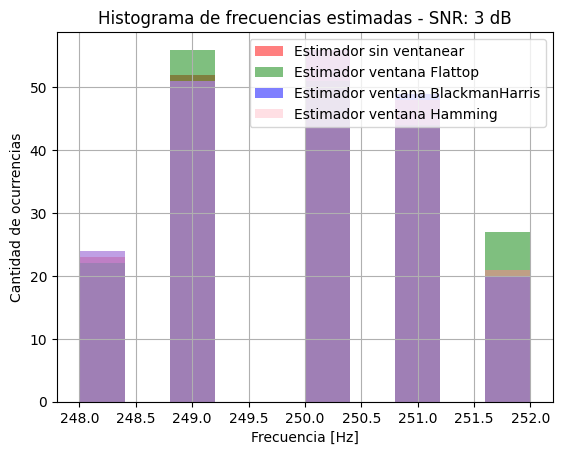

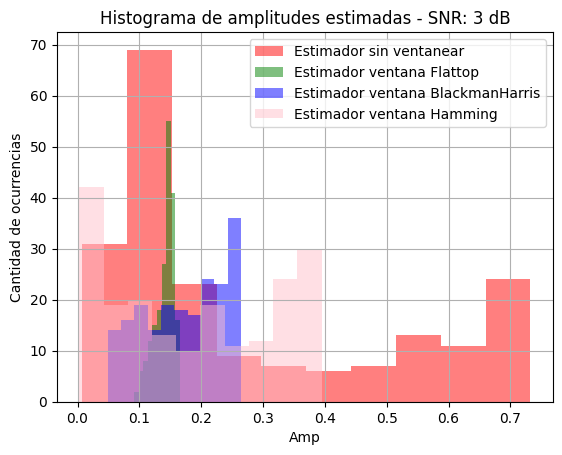

In [15]:
#%% DEFINIR ESTIMADOR DE AMPLITUD = a1
# valor verdadero = a0
a_R = np.abs(X_FFT0[N//4, :])
a_FT = np.abs(XFT_FFT[N//4, :])
a_BMH =  np.abs(XBMH_FFT0[N//4, :])
a_H = np.abs(XH_FFT0[N//4, :])

#%% Definir estimador de Frecs = omega
# valor verdadero = w0
w_R = np.argmax(X_FFT, axis=0) * df  
w_FT = np.argmax(XFT_FFT, axis =0)* df
w_BMH = np.argmax(XBMH_FFT, axis =0)* df 
w_H = np.argmax(XH_FFT, axis=0)* df 

#%% GRAFICOS 
####Histograma omega
plt.figure()
plt.hist(w_R, bins=10, color='red',fill= 'True', alpha=0.5, label="Estimador sin ventanear")
plt.hist(w_FT, bins=10,color='green',fill= 'True', alpha=0.5, label="Estimador ventana Flattop")
plt.hist(w_BMH, bins=10, color='blue',fill= 'True', alpha=0.5,label="Estimador ventana BlackmanHarris")
plt.hist(w_H, bins=10,  color='pink',fill= 'True', alpha=0.5, label="Estimador ventana Hamming")
plt.title(f"Histograma de frecuencias estimadas - SNR: {SNR} dB")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Cantidad de ocurrencias")
plt.grid(True)
plt.legend()
plt.show()

# Histograma a
plt.figure()
plt.hist(a_R, bins=10, color='red', alpha=0.5, label="Estimador sin ventanear") #Bins: resolucion espectral del histograma; conteo relativo. ANCHURA de los valores.
plt.hist(a_FT, bins=10, color='green', alpha=0.5, label="Estimador ventana Flattop")
plt.hist(a_BMH, bins=10, color='blue', alpha=0.5, label="Estimador ventana BlackmanHarris")
plt.hist(a_H, bins=10, color='pink', alpha=0.5, label="Estimador ventana Hamming")
plt.title(f"Histograma de amplitudes estimadas - SNR: {SNR} dB")
plt.xlabel("Amp")
plt.ylabel("Cantidad de ocurrencias")
plt.grid(True)
plt.legend()
plt.show()

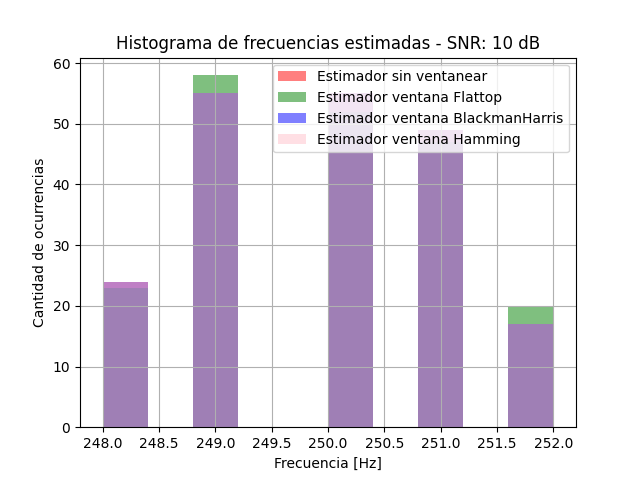

In [16]:
from IPython.display import Image
Image("C:/Users/magui/Desktop/APS - 1er C 2026/TS 4/hist Frecs 10dB.png")

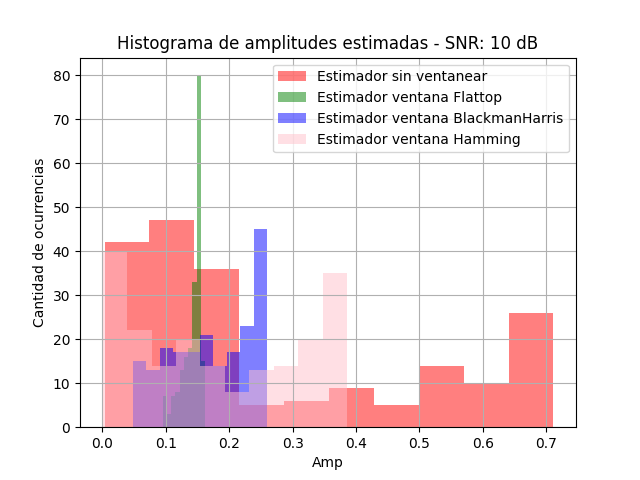

In [17]:
from IPython.display import Image
Image("C:/Users/magui/Desktop/APS - 1er C 2026/TS 4/hist Amps 10dB.png")

Al analizar los histogramas de amplitudes se pueden observar comportamientos bien diferenciados según el tipo de ventana y el nivel de SNR. En cuanto a las distintas ventanas, el estimador con Flattop (verde) es claramente el más preciso, mostrando una distribución muy angosta y concentrada en ambos niveles de SNR, mientras que el estimador sin ventanear (rojo) presenta la mayor dispersión con colas que se extienden hasta valores muy alejados del verdadero, consecuencia directa del leakage espectral producido por la frecuencia fuera de grilla. BlackmanHarris (azul) se ubica como segunda mejor opción y Hamming (rosa) en un punto intermedio entre este y el sin ventanear. Al bajar el SNR de $10dB$ a $3dB$, todos los estimadores de amplitud se degradan, ensanchando sus distribuciones y aumentando su varianza. 

Para la estimación de frecuencia, el panorama se invierte: los estimadores sin ventanear (rojo), BlackmanHarris (azul) y Hamming (rosa) se comportan de manera prácticamente idéntica, concentrando sus estimaciones en el rango esperado de $[248;252] Hz$ alrededor de la frecuencia verdadera de $250 Hz$, mientras que Flattop (verde) es el peor, ya que su lóbulo principal ancho dificulta la identificación precisa del pico espectral. La reducción del SNR también afecta la estimación de frecuencia, aunque de forma más moderada que en la amplitud, produciendo una leve dispersión adicional hacia los extremos del rango. 

Por ultimo, para describir a los estimadores de forma numerica, se calcula su SESGO, que mide que 'tan lejos' se encuentra elestimador del valor real y la VARIANZA, que representa que tanto se disperza el estimados alrededor de su propia medida. Los resultados se presentan en tablas, una para cada valor de SNR. 

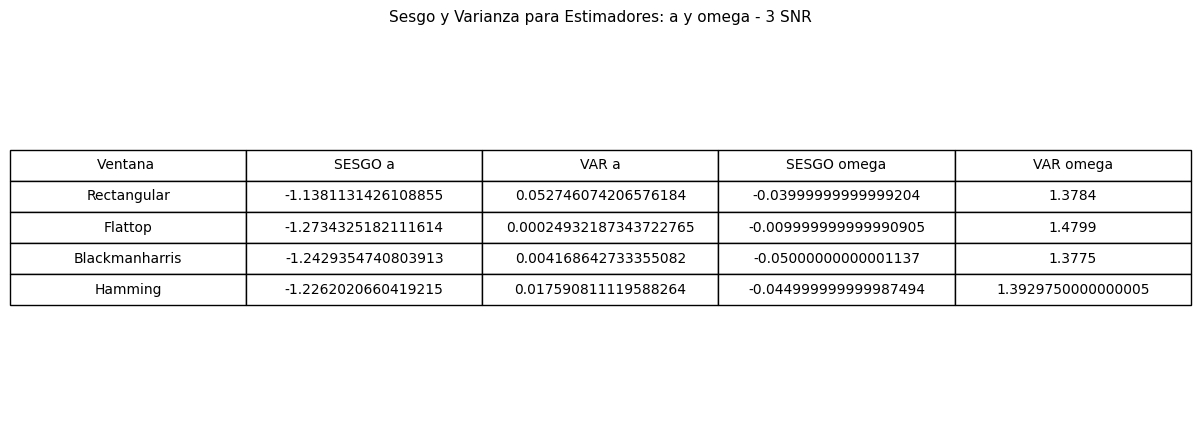

In [18]:
#%% DEFINIR ESTIMADOR DE AMPLITUD = a1
# SESGO 
# Calculo el valor promedio de cada estimador --> 'valor esperado'
E_a_R = np.mean(a_R)
E_a_FT = np.mean(a_FT)
E_a_BMH = np.mean(a_BMH)
E_a_H = np.mean(a_H)
#Sesgo = valor promedio - valor real 
S_a_R = E_a_R - a0
S_a_FT = E_a_FT - a0
S_a_BMH = E_a_BMH - a0
S_a_H = E_a_H - a0

#VARIANZA 
V_a_R = np.var(a_R)
V_a_FT = np.var(a_FT)
V_a_BMH = np.var(a_BMH)
V_a_H = np.var(a_H)

#%% Definir estimador de Frecs = omega
#SESGO 
#valor real = w0
E_w_R = np.mean(w_R)  
E_w_FT = np.mean(w_FT)
E_w_BMH = np.mean(w_BMH)
E_w_H = np.mean(w_H)
#Sesgo = valor promedio - valor real 
S_w_R = E_w_R - w0
S_w_FT = E_w_FT - w0
S_w_BMH = E_w_BMH - w0
S_w_H = E_w_H - w0

#VARIANZA
V_w_R = np.var(w_R)
V_w_FT = np.var(w_FT)
V_w_BMH = np.var(w_BMH)
V_w_H = np.var(w_H)

#%% GRAFICOS
##Crear tabla con los encabezados fijos
tabla = [
    ["Ventana ",     "SESGO a",      "VAR a",      "SESGO omega",      "VAR omega"],
    ["Rectangular", S_a_R, V_a_R, S_w_R , V_w_R],
    ["Flattop", S_a_FT,  V_a_FT, S_w_FT, V_w_FT],
    ["Blackmanharris", S_a_BMH,  V_a_BMH, S_w_BMH, V_w_BMH],
    ["Hamming", S_a_H,  V_a_H, S_w_H, V_w_H]
]

# Mostrar como imagen
fig, ax = plt.subplots(figsize=(12, 2 + len(tabla)*0.5))
ax.axis('tight')
ax.axis('off')
plt.title(f"Sesgo y Varianza para Estimadores: a y omega - {SNR} SNR", fontsize=11, pad=1)
table = ax.table(cellText=tabla, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)
plt.tight_layout()
plt.show()

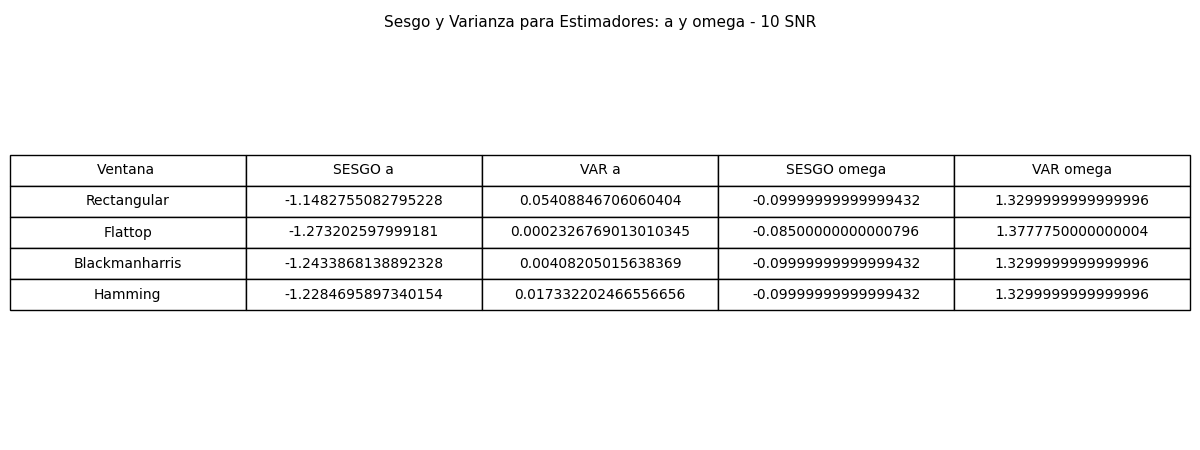

In [19]:
from IPython.display import Image
Image("C:/Users/magui/Desktop/APS - 1er C 2026/TS 4/tabla 10dB.png")

Al analizar los valores de sesgo y varianza para ambos SNR se pueden extraer conclusiones sobre el comportamiento de cada estimador. En cuanto a la estimación de amplitud, Flattop presenta la menor varianza en ambos casos, confirmando numéricamente lo observado en los histogramas, aunque su sesgo es el más negativo de todos ($\approx-1.28$), lo que indica que subestima sistemáticamente la amplitud verdadera debido al leakage. BlackmanHarris le sigue con una varianza intermedia, mientras que Hamming y Rectangular presentan las mayores varianzas, siendo Hamming el peor en este aspecto. Para la estimación de frecuencia, los sesgos son pequeños y similares entre todos los estimadores, del orden de $0.03–0.06$ Hz, lo cual es esperable dado que la perturbación es uniforme y centrada en cero. Sin embargo, la varianza de frecuencia es notablemente alta en todos los casos ($\approx 1.3–1.6$), reflejando la dispersión introducida por la perturbación aleatoria de $\pm 2$. Al comparar los dos niveles de SNR, se observa que pasar de $3 dB$ a $10 dB$ mejora levemente la varianza de amplitud en todos los estimadores, pero no produce cambios significativos en el sesgo ni en las métricas de frecuencia.

A lo largo del trabajo se estimaron la amplitud y la frecuencia de una señal senoidal con frecuencia aleatoria, bajo dos niveles de ruido, utilizando cuatro estimadores espectrales distintos. Los resultados obtenidos son consistentes con el comportamiento teorico esperado de cada ventana: Flattop, diseñada especificamente para estimacion de amplitud, mostro la menor varianza  pero resultó inadecuada para estimar frecuencia, mientras que las ventanas Rectangular, BlackmanHarris y Hamming lograron mejores estimaciones de frecuencia a costa de una mayor dispersión en amplitud. El hecho de que el sesgo en amplitud sea grande y negativo para todos los estimadores se explica por el leakage espectral introducido al no caer la señal exactamente en una frecuencia de la grilla del DFT, efecto que ninguna ventana logra eliminar completamente. Por su parte, la alta varianza en la estimación de frecuencia responde directamente a la perturbación aleatoria de $\pm2$  aplicada a la señal, siendo este el factor dominante por encima del nivel de ruido. Finalmente, la reducción del SNR de 10 dB a 3 dB impacta principalmente en la estimación de amplitud, degradando la varianza de todos los estimadores, mientras que su efecto sobre la frecuencia es secundario.